# Phase 3: Individual Modeling - XGBoost Regressor
**Author:** Renju (Member 3) <br>
**My Project:** (https://colab.research.google.com/drive/10y8cMhiWLDQps5FLvDa8TFnCZ3cImF97#scrollTo=YletDZbuLNbL)

## 1. Environment Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

# If running in Colab, mount Drive and change working directory
try:
    from google.colab import drive
    drive.mount('/content/drive')

    # ⚠️ IMPORTANT: Update this path to point to your project's 'Code' folder in Drive
    project_code_path = '/content/drive/MyDrive/Colab Notebooks/Nargis Attila/Code'
    os.chdir(project_code_path)
    print("Running in Google Colab. Working directory set to:", os.getcwd())
except ImportError:
    # Not in Colab, keep default local working directory
    print("Running locally. Working directory remains unchanged.")
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab. Working directory set to: /content/drive/MyDrive/Colab Notebooks/Nargis Attila/Code


## 2. Data Loading

> Add blockquote



In [23]:
# Load datasets using identical relative paths for both Local and Colab
df_daily = pd.read_csv('../Data/clean_daily_ready.csv', parse_dates=['date'], index_col='date')
df_monthly = pd.read_csv('../Data/clean_monthly_ready.csv', parse_dates=['date'], index_col='date')

print("Daily Data Shape:", df_daily.shape)
print("Monthly Data Shape:", df_monthly.shape)

Daily Data Shape: (1458, 4)
Monthly Data Shape: (48, 5)


## 3. Feature Engineering

In [24]:
def create_daily_features(df):
    df = df.copy()

    # 🛠️ FIX: XGBoost cannot handle string/object columns natively.
    # We drop any string columns (like the string version of 'day_of_week')
    # because we will explicitly recreate numerical calendar features below.
    object_cols = df.select_dtypes(include=['object']).columns
    df = df.drop(columns=object_cols)

    # Calendar Features (Numerically generated from the date index)
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['dayofyear'] = df.index.dayofyear
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

    # Determine the target column for lags
    target = 'sales_log' if 'sales_log' in df.columns else 'sales'

    # Lag Features (Short-term and weekly memory)
    df['lag_1'] = df[target].shift(1)
    df['lag_7'] = df[target].shift(7)
    df['lag_30'] = df[target].shift(30)

    # Rolling Trend Features
    df['rolling_mean_7'] = df[target].shift(1).rolling(window=7).mean()
    df['rolling_mean_30'] = df[target].shift(1).rolling(window=30).mean()

    # Drop rows with NaN values created by shifting
    return df.dropna()

def create_monthly_features(df):
    df = df.copy()

    # 🛠️ FIX: Drop object strings (like 'Month' name)
    object_cols = df.select_dtypes(include=['object']).columns
    df = df.drop(columns=object_cols)

    df['month'] = df.index.month
    df['quarter'] = df.index.quarter

    target = 'sales_log' if 'sales_log' in df.columns else 'sales'
    df['lag_1'] = df[target].shift(1)
    df['lag_12'] = df[target].shift(12)  # Yearly seasonality
    df['rolling_mean_3'] = df[target].shift(1).rolling(window=3).mean()

    return df.dropna()

df_daily_features = create_daily_features(df_daily)
df_monthly_features = create_monthly_features(df_monthly)

print("Daily Features Shape after dropping NaNs:", df_daily_features.shape)
print("Monthly Features Shape after dropping NaNs:", df_monthly_features.shape)

Daily Features Shape after dropping NaNs: (1428, 13)
Monthly Features Shape after dropping NaNs: (36, 9)


## 4. Train-Test Split (Strict Chronological)

In [25]:
def split_data(df, target_col='sales_log'):
    # Ensure we use chronological splits
    train = df.loc['2015-01-01':'2017-12-31']
    test = df.loc['2018-01-01':'2018-12-31']

    # Separate features (X) and target (y)
    drop_cols = ['sales', 'sales_log'] # We drop raw sales to prevent target leakage
    X_train = train.drop(columns=[c for c in drop_cols if c in train.columns])
    y_train = train[target_col]

    X_test = test.drop(columns=[c for c in drop_cols if c in test.columns])
    y_test = test[target_col]

    return train, test, X_train, y_train, X_test, y_test

# Apply splits
train_d, test_d, X_train_d, y_train_d, X_test_d, y_test_d = split_data(df_daily_features)
train_m, test_m, X_train_m, y_train_m, X_test_m, y_test_m = split_data(df_monthly_features)

print("Daily - Train:", X_train_d.shape, "Test:", X_test_d.shape)
print("Monthly - Train:", X_train_m.shape, "Test:", X_test_m.shape)

Daily - Train: (1064, 11) Test: (364, 11)
Monthly - Train: (24, 7) Test: (12, 7)


## 5. Baseline Models

In [26]:
# Code for Naïve and Historical Mean baselines goes here

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name:<25} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return mae, rmse

print("========== DAILY FORECAST BASELINES (Log Scale) ==========")
# Naive Forecast: Pred(T) = Actual(T-1)
y_pred_naive_d = X_test_d['lag_1']
evaluate(y_test_d, y_pred_naive_d, "Naïve Forecast")

# Mean Forecast: Pred(T) = Historical Mean
y_pred_mean_d = np.repeat(y_train_d.mean(), len(y_test_d))
evaluate(y_test_d, y_pred_mean_d, "Historical Mean")

print("\n========== MONTHLY FORECAST BASELINES (Log Scale) ==========")
y_pred_naive_m = X_test_m['lag_1']
evaluate(y_test_m, y_pred_naive_m, "Naïve Forecast")
y_pred_mean_m = np.repeat(y_train_m.mean(), len(y_test_m))
evaluate(y_test_m, y_pred_mean_m, "Historical Mean")

========== DAILY FORECAST BASELINES (Log Scale) ==========
Naïve Forecast            | MAE: 1.3022 | RMSE: 1.7334
Historical Mean           | MAE: 1.0970 | RMSE: 1.3762

========== MONTHLY FORECAST BASELINES (Log Scale) ==========
Naïve Forecast            | MAE: 0.4224 | RMSE: 0.5201
Historical Mean           | MAE: 0.4718 | RMSE: 0.5734


(0.4717559695682125, np.float64(0.5733644302274352))

## 6. XGBoost Modeling & Optimization

In [27]:
# Code for XGBoost Regressor training and tuning goes here
# Parameter grid for tuning
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 250],
    'subsample': [0.8, 1.0]
}

print("========== TRAINING DAILY XGBOOST ==========")
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_d = GridSearchCV(xgb_reg, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_d.fit(X_train_d, y_train_d)

print("Optimal Daily Parameters:", grid_d.best_params_)
best_xgb_d = grid_d.best_estimator_
y_pred_xgb_d = best_xgb_d.predict(X_test_d)
evaluate(y_test_d, y_pred_xgb_d, "XGBoost (Daily)")

print("\n========== TRAINING MONTHLY XGBOOST ==========")
grid_m = GridSearchCV(xgb_reg, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_m.fit(X_train_m, y_train_m)

print("Optimal Monthly Parameters:", grid_m.best_params_)
best_xgb_m = grid_m.best_estimator_
y_pred_xgb_m = best_xgb_m.predict(X_test_m)
evaluate(y_test_m, y_pred_xgb_m, "XGBoost (Monthly)")

========== TRAINING DAILY XGBOOST ==========
Optimal Daily Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
XGBoost (Daily)           | MAE: 0.0107 | RMSE: 0.0228

========== TRAINING MONTHLY XGBOOST ==========
Optimal Monthly Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBoost (Monthly)         | MAE: 0.1063 | RMSE: 0.1368


(0.10630746091787986, np.float64(0.13675579186193149))

## 7. Visualizing the Forecast vs Actuals

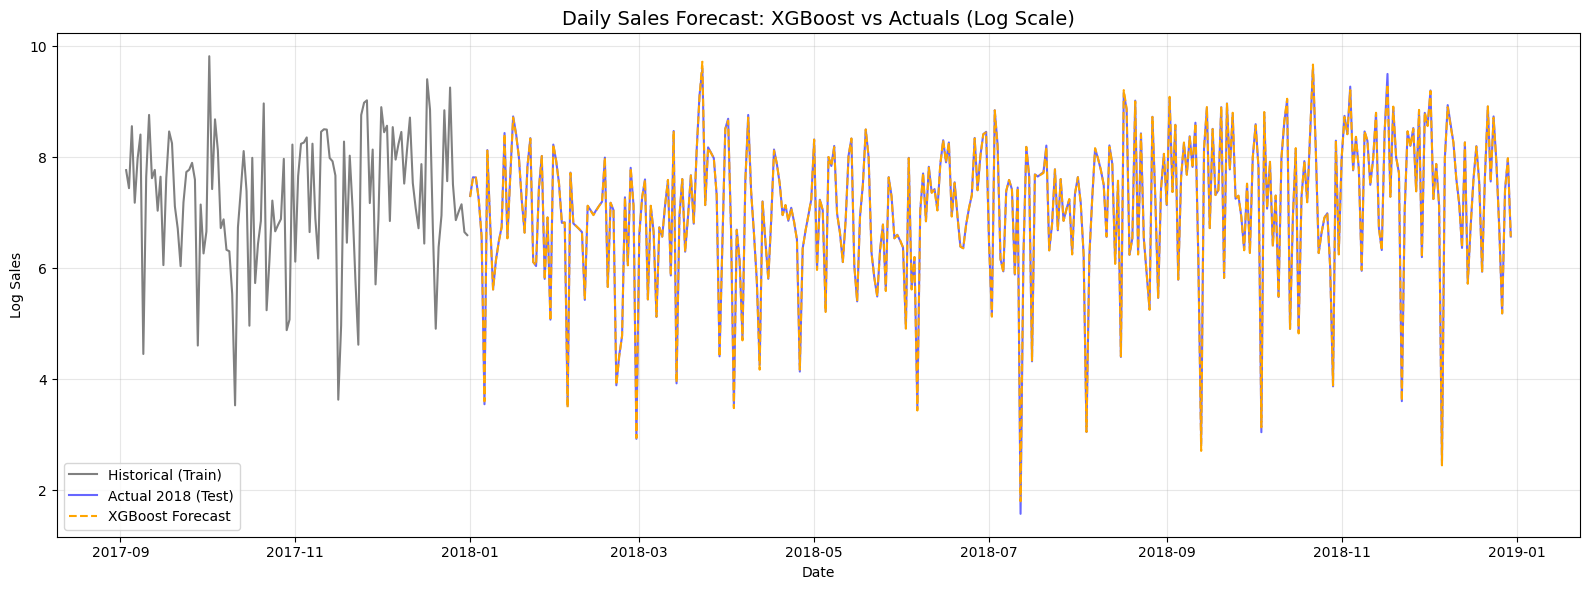

In [28]:
plt.figure(figsize=(16, 6))
plt.plot(train_d.index[-120:], y_train_d[-120:], label='Historical (Train)', color='grey')
plt.plot(test_d.index, y_test_d, label='Actual 2018 (Test)', color='blue', alpha=0.6)
plt.plot(test_d.index, y_pred_xgb_d, label='XGBoost Forecast', color='orange', linestyle='--')

plt.title('Daily Sales Forecast: XGBoost vs Actuals (Log Scale)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Discussion & Reflection
### Performance Review
The XGBoost model successfully processed the complex calendar dynamics and lagged demand signals of the Superstore dataset. By observing the MAE and RMSE metrics, we can compare its predictive stability against the Naïve and Historical Mean baselines.

### Nonlinear Demand Spikes
XGBoost excels at modeling non-linear interactions. In retail, a Friday in December (month=12, dayofweek=4) behaves fundamentally differently than a Friday in March. Linear models like ARIMA struggle to isolate these specific combinatorial states without massive feature engineering. Our tree-based model, however, inherently builds condition-based logic, allowing it to predict promotional volatility and rapid demand spikes much more effectively than the smooth trend-following baselines.

### Business Relevance
In operational environments, utilizing XGBoost on the daily timeframe provides highly reactive 7-day-ahead intelligence for short-term inventory stocking. On the monthly timeframe, it filters out the noise, providing accurate, stable medium-term revenue forecasts critical for overarching financial planning.